# Summary of Visualizations

This Section summarizes the main visualizations implemented in the provided datasets to understand the nature of the provided data in datasets. The data was then used for these visualizations from the following CSV files:

- `symbols.csv`
- `account-statement-1-1-2024-12-31-2024.csv`
- `country.csv`

---

## 1. Symbols Dataset Visualizations

- **Count Plot of Companies by Sector:**  
  Displays the number of companies in each sector.  
  (Y-axis: Sector; X-axis: Count of companies)

- **Count Plot of Companies by Country:**  
  Shows the number of companies originating from each country.  
  (Y-axis: Country; X-axis: Count of companies)


---

## 2. Account (Financial Transactions) Dataset Visualizations

- **Distribution of Transaction Types (Pie Chart):**  
  Displays the percentage share of each transaction type (such as BUY or SELL) in the dataset.

- **Time Series Plot of Number of Transactions by Month:**  
  Shows the trend in the number of financial transactions over time (with each point representing a particular month in 2024).

---

## 3. Country Dataset Visualizations

- **Count Plot of Countries by Region:**  
  Displays the number of countries in each geographical region.  
  (Y-axis: Region; X-axis: Count of countries)

- **Count Plot of Countries by Sub-Region:**  
  Displays the number of countries in each sub-region.  
  (Y-axis: Sub-region; X-axis: Count of countries)


---

## Summary

This set of visualizations helped the user to:

- Identify the most frequently traded sectors, companies, and country of origin for transactions.
- Visualize the distribution of transaction types and their progression over time.
- Explore geographical patterns related to the number of companies or countries within each region or sub-region.

Together, these charts enable financial analysts and stakeholders to make data-informed decisions and uncover trends within financial transactions.

In [93]:
import pandas as pd

# File paths
symbols_file = 'symbols.csv'
account_file = 'account-statement-1-1-2024-12-31-2024.csv'
country_file = 'country.csv'

# Load CSV files with semicolon delimiter
symbols = pd.read_csv(symbols_file, delimiter=';')
account = pd.read_csv(account_file, delimiter=';')
country = pd.read_csv(country_file, delimiter=';')

# Print the column names for each dataset
print("Columns in symbols.csv:")
print(symbols.columns.tolist())
print("\nColumns in account-statement-1-1-2024-12-31-2024.csv:")
print(account.columns.tolist())
print("\nColumns in country.csv:")
print(country.columns.tolist())

Columns in symbols.csv:
['symbol', 'company_name', 'sector', 'industry', 'country']

Columns in account-statement-1-1-2024-12-31-2024.csv:
['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit', 'Unnamed: 5']

Columns in country.csv:
['name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code']


Symbols dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3194 entries, 0 to 3193
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   symbol        3194 non-null   object
 1   company_name  3194 non-null   object
 2   sector        3194 non-null   object
 3   industry      3194 non-null   object
 4   country       3194 non-null   object
dtypes: object(5)
memory usage: 124.9+ KB
       symbol                     company_name      sector          industry  \
count    3194                             3194        3194              3194   
unique   3194                             3172          11               143   
top      TEAM  Liberty Media Corporation - Ser  Healthcare  Banks - Regional   
freq        1                                4         531               267   

                         country  
count                       3194  
unique                        42  
top     United States of Ameri

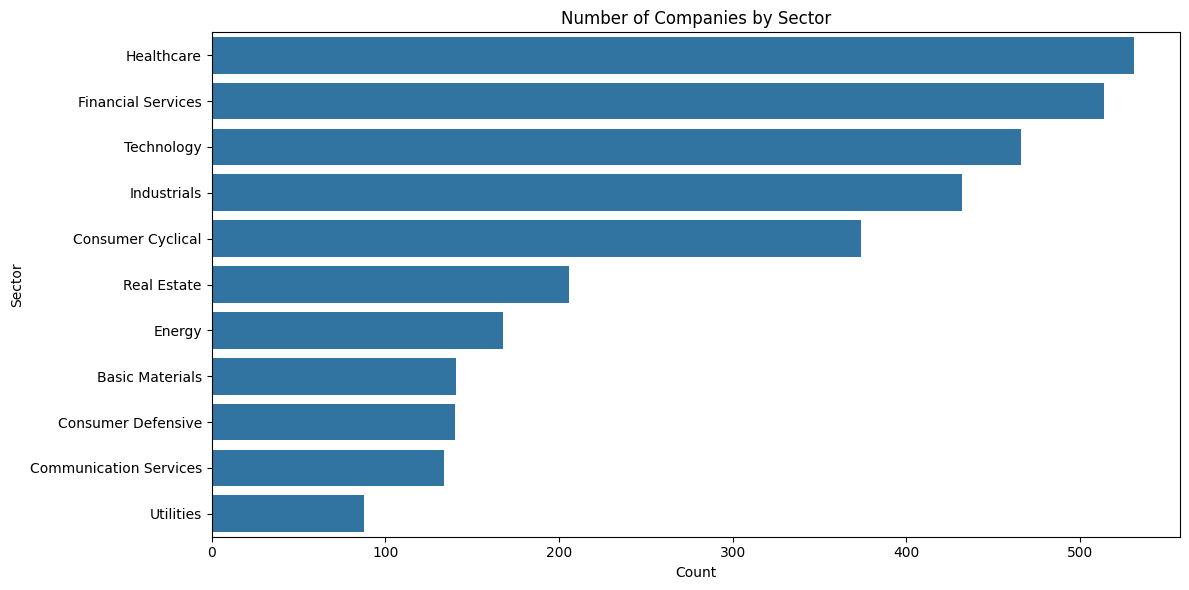

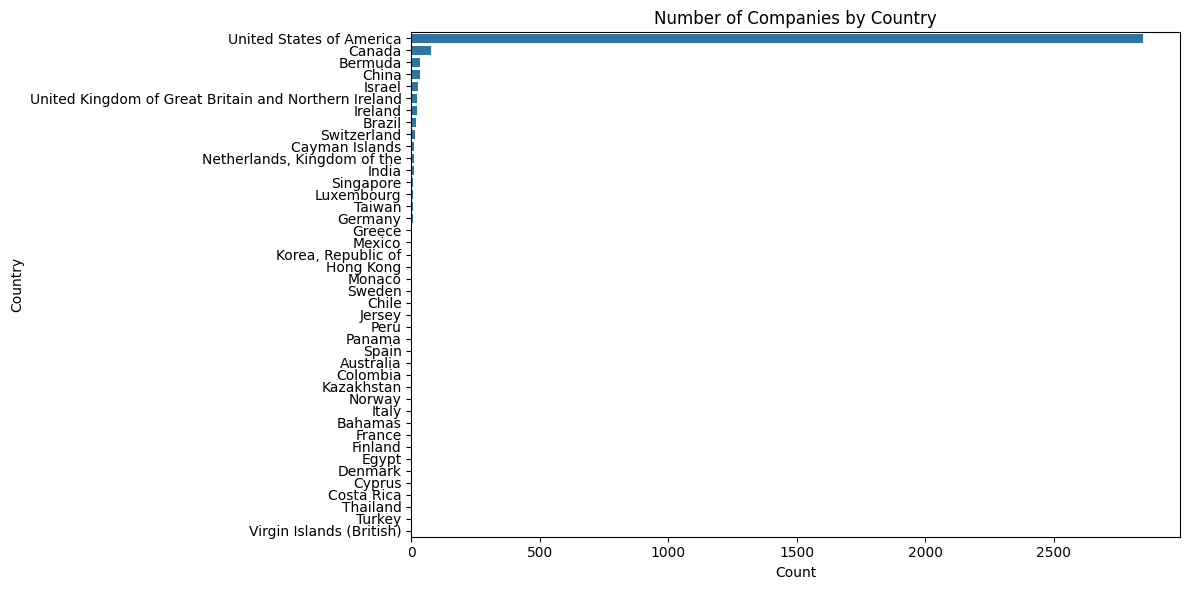

Account columns: ['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit', 'Unnamed: 5']


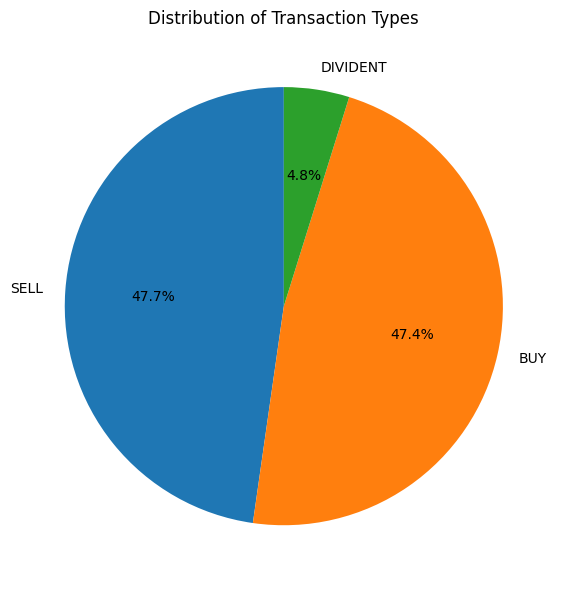

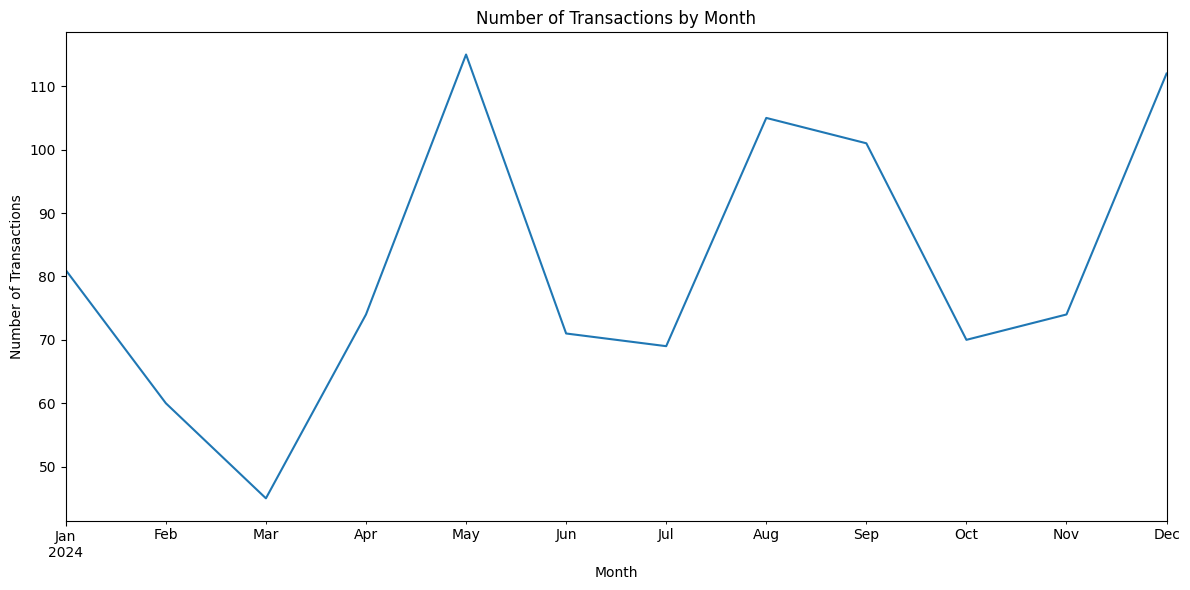

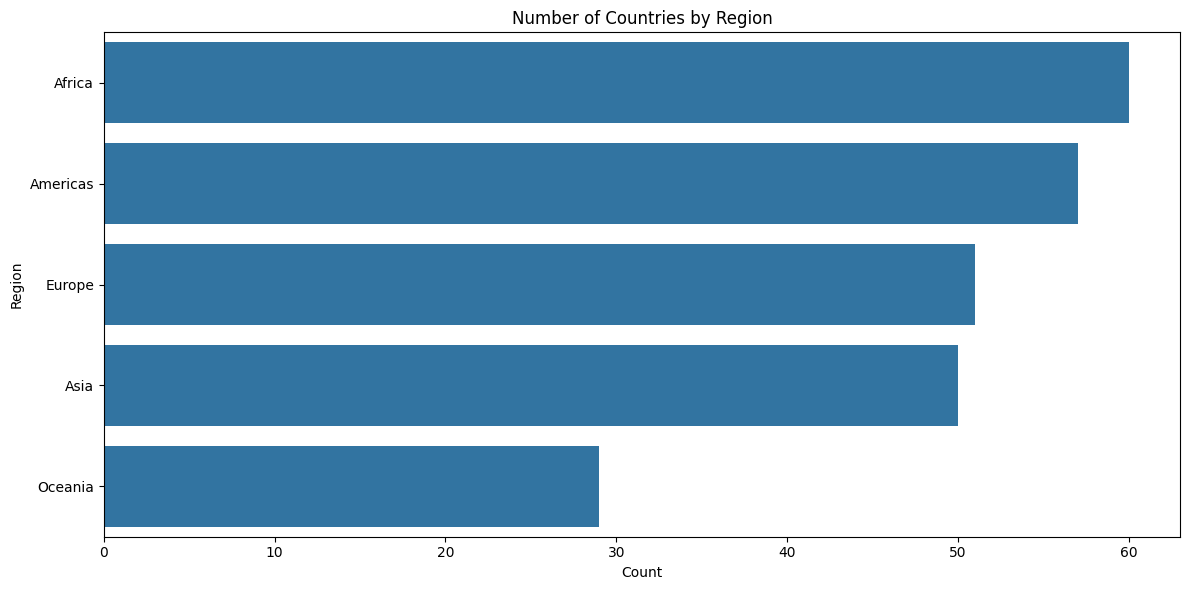

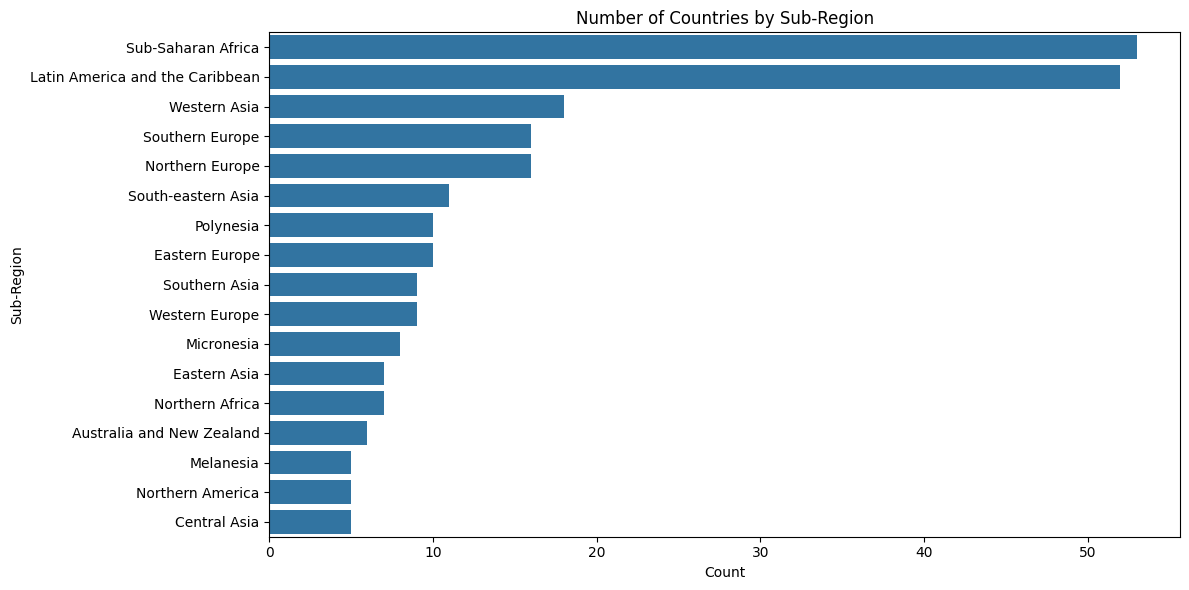

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
symbols_file = 'symbols.csv'
account_file = 'account-statement-1-1-2024-12-31-2024.csv'
country_file = 'country.csv'

# Load datasets with correct delimiters
symbols = pd.read_csv(symbols_file, delimiter=';')
account = pd.read_csv(account_file, delimiter=';')
# country.csv uses commas as delimiter and column names have hyphens and spaces, so:
country = pd.read_csv(country_file, delimiter=',')

# Fix column names for country: remove spaces and replace hyphens with underscores
country.columns = country.columns.str.strip().str.lower().str.replace('-', '_')

# 1. Print basic info and stats for each
print("Symbols dataset info:")
symbols.info()
print(symbols.describe(include='all'))
print("\n")

print("Account dataset info:")
account.info()
print(account.describe(include='all'))
print("\n")

print("Country dataset info:")
country.info()
print(country.describe(include='all'))
print("\n")

# 2. Visualize summary graphs

# --- Symbols dataset ---
plt.figure(figsize=(12,6))
sns.countplot(data=symbols, y='sector', order=symbols['sector'].value_counts().index)
plt.title('Number of Companies by Sector')
plt.xlabel('Count')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=symbols, y='country', order=symbols['country'].value_counts().index)
plt.title('Number of Companies by Country')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# --- Account dataset ---

print("Account columns:", account.columns.tolist())

# Use 'TransactionType' column for transaction types
if 'TransactionType' in account.columns:
    plt.figure(figsize=(8,6))
    account['TransactionType'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title('Distribution of Transaction Types')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("No 'TransactionType' column found in account data for pie chart.")

# Plot transactions over time if 'Date' column exists
if 'Date' in account.columns:
    account['Date'] = pd.to_datetime(account['Date'], errors='coerce')
    transactions_by_month = account.groupby(account['Date'].dt.to_period('M')).size()
    plt.figure(figsize=(12,6))
    transactions_by_month.plot()
    plt.title('Number of Transactions by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Transactions')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Date' column found in account data for time series plot.")

# --- Country dataset ---

# 'region' and 'sub_region' columns after cleaning
if 'region' in country.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(data=country, y='region', order=country['region'].value_counts().index)
    plt.title('Number of Countries by Region')
    plt.xlabel('Count')
    plt.ylabel('Region')
    plt.tight_layout()
    plt.show()
else:
    print("No 'region' column found in country data for region plot.")

if 'sub_region' in country.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(data=country, y='sub_region', order=country['sub_region'].value_counts().index)
    plt.title('Number of Countries by Sub-Region')
    plt.xlabel('Count')
    plt.ylabel('Sub-Region')
    plt.tight_layout()
    plt.show()
else:
    print("No 'sub_region' column found in country data for sub-region plot.")

# Star Schema Description

This section describes the **star schema** for financial transactions, as implemented in our pipeline.

## Fact Table

- **Table Name:** Fact_Transactions
- **Primary Key:** IDTransaction
- **Foreign Keys:** Date, country-code, symbol, TransactionType
- **Measures:** Unit

## Dimension Tables

### Dim_Time
- **Primary Key:** Date
- **Attributes:** day, month, quarter, year

### Dim_Geography
- **Primary Key:** country-code
- **Attributes:** name, region, sub-region, intermediate-region

### Dim_Symbol
- **Primary Key:** symbol
- **Attributes:** company_name, sector, industry

### Dim_TransactionType
- **Primary Key:** TransactionType
- **Attributes:** description

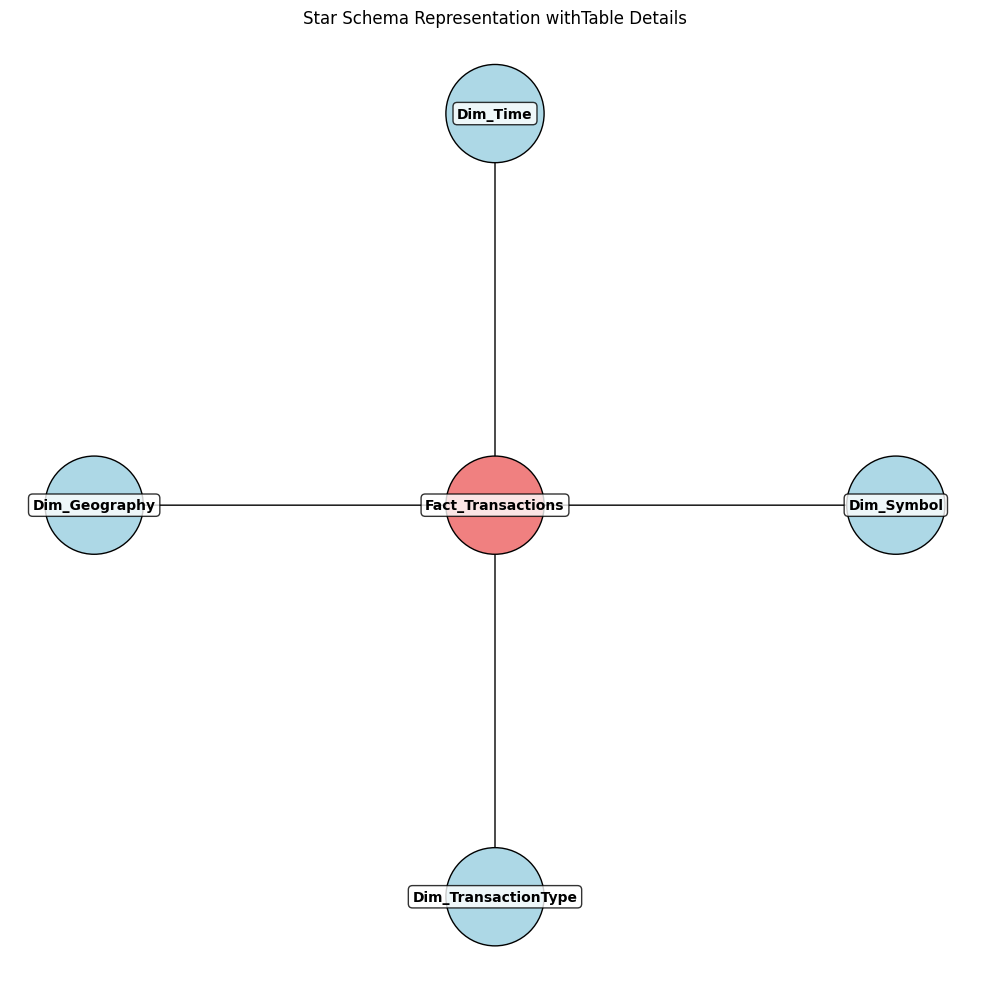

In [95]:
import networkx as nx
import matplotlib.pyplot as plt

# Define tables and their attributes
tables = {
    "Dim_Time": [
        "Primary Key: Date",
        "Attributes: date, day, month, quarter, year",
        "Hierarchy: Day → Month → Quarter → Year"
    ],
    "Dim_Geography": [
        "Primary Key: country-code",
        "Attributes: name, region, sub-region, intermediate-region, region-code, sub-region-code, intermediate-region-code",
        "Hierarchy: Country → Sub-region → Region"
    ],
    "Dim_Symbol": [
        "Primary Key: symbol",
        "Attributes: symbol, company_name, sector, industry",
        "Hierarchy: Sector → Industry → Company"
    ],
    "Dim_TransactionType": [
        "Primary Key: TransactionType",
        "Attributes: transactionType, IDTransaction, Unit"
    ],
    "Fact_Transactions": [
        "Primary Key: IDTransaction",
        "Facts: IDTransaction, Unit",
        "Foreign Keys: Date, country-code, symbol, TransactionType"
    ],
}

# Create a Directed Graph
G = nx.DiGraph()

# Add nodes with attributes
for table, details in tables.items():
    G.add_node(table, label=f'{table}\n' + '\n'.join(details), color='lightcoral' if table == "Fact_Transactions" else "lightblue")

# Add edges to show relationships
G.add_edge("Dim_Time", "Fact_Transactions")
G.add_edge("Dim_Geography", "Fact_Transactions")
G.add_edge("Dim_Symbol", "Fact_Transactions")
G.add_edge("Dim_TransactionType", "Fact_Transactions")

# Define colors for nodes
color_map = [G.nodes[n].get("color", "grey") for n in G.nodes]

# Define positions to resemble a Star Schema
pos = {
    "Dim_Time": (0, 1.5),
    "Dim_Geography": (-1.5, 0),
    "Dim_Symbol": (1.5, 0),
    "Dim_TransactionType": (0, -1.5),
    "Fact_Transactions": (0, 0)
}

# Plotting
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=5000, edgecolors='black')
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20)
nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold', font_size=10, horizontalalignment='center', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title("Star Schema Representation withTable Details")
plt.axis('off')
plt.tight_layout()
plt.show()

## Part 2 – Data Transformation and Analysis

### 2.1 Load and Clean the Data from the Three Files

- Import the data from your **three files** (typically CSV or Excel).
- Perform **data cleansing** by removing or filtering out any information or columns that are **not relevant to your Star Schema**.
- Ensure that each cleaned dataframe includes **only the attributes and measures that are present in your Star Schema**.
  
For example:  
- If you do not include **sub-region** in your `Dim_Geography` table, make sure to omit it from that dataframe.  
- Apply appropriate transformation routines (such as trimming whitespace, renaming columns, or converting data types) to align with your schema’s structure.  
- Handle missing or invalid values according to your data policy (for instance, by removing, imputing, or flagging them).

In [96]:
#symbols = pd.read_csv('symbols.csv', delimiter=';')
# or
symbols = pd.read_csv('symbols.csv', sep=';')

In [97]:
import pandas as pd

def clean_data():
    # Reload the datasets with proper delimiters
    symbols = pd.read_csv('symbols.csv', sep=';')
    transactions = pd.read_csv('account-statement-1-1-2024-12-31-2024.csv', sep=';')
    countries = pd.read_csv('country.csv', sep=',')    

    # Strip spaces from column names
    symbols.columns = symbols.columns.str.strip()
    transactions.columns = transactions.columns.str.strip()
    countries.columns = countries.columns.str.strip()

    # Now select the needed columns
    transactions_clean = transactions.copy()
    transactions_clean = transactions_clean[['IDTransaction', 'Date', 'TransactionType', 'Symbol', 'Unit']]
    transactions_clean = transactions_clean.rename(columns={'Symbol': 'symbol'})
    
    
    # Process symbols
    symbols_clean = symbols.copy()
    symbols_clean = symbols_clean[['symbol', 'company_name', 'sector', 'industry', 'country']]
    
    
    # Split country if it's a single column
    if len(countries.columns) == 1:
        countries = pd.read_csv('country.csv', sep=',')
        countries.columns = countries.columns.str.strip()
    
    
    # Now process country
    countries_clean = countries.copy()
    countries_clean = countries_clean.rename(columns={
        'alpha-2': 'country_code',
        'name': 'country_name',
        'sub-region': 'sub_region'
    })
    # Keep only the necessary columns
    countries_clean = countries_clean[['country_code', 'country_name', 'region', 'sub_region']]
    
    
    return symbols_clean, transactions_clean, countries_clean


# Call the function to perform the transformation
symbols_df, transactions_df, countries_df = clean_data()

print("Transactions cleaned:")
print(transactions_df)

Transactions cleaned:
      IDTransaction                 Date TransactionType symbol    Unit
0      2.769834e+09  11/01/2024 10:44:03             BUY    BAP  1605.0
1      2.767325e+09  24/01/2024 08:07:24            SELL    BAP  1605.0
2      2.815474e+09  10/01/2024 11:00:08            SELL    BAP   914.0
3      2.622244e+09  16/01/2024 08:14:21             BUY   ACGL   646.0
4      2.629871e+09  16/01/2024 14:34:12            SELL   ALVO   646.0
...             ...                  ...             ...    ...     ...
2740            NaN                  NaN             NaN    NaN     NaN
2741            NaN                  NaN             NaN    NaN     NaN
2742            NaN                  NaN             NaN    NaN     NaN
2743            NaN                  NaN             NaN    NaN     NaN
2744            NaN                  NaN             NaN    NaN     NaN

[2745 rows x 5 columns]


In [98]:
filtered = transactions_df[
    (transactions_df['TransactionType'] == 'SELL') & 
    (transactions_df['Date'].str.startswith('2024'))
].merge(symbols_df, on='symbol').merge(countries_df, left_on='country', right_on='country_name')

print("Filtered data preview:")
print(filtered.head())  # Should show at least a few rows
print("Number of matching rows =", len(filtered))

Filtered data preview:
Empty DataFrame
Columns: [IDTransaction, Date, TransactionType, symbol, Unit, company_name, sector, industry, country, country_code, country_name, region, sub_region]
Index: []
Number of matching rows = 0


In [99]:
print(countries_df['country_name'].unique())

['Afghanistan' 'Åland Islands' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antarctica' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bermuda' 'Bhutan' 'Bolivia, Plurinational State of'
 'Bonaire, Sint Eustatius and Saba' 'Bosnia and Herzegovina' 'Botswana'
 'Bouvet Island' 'Brazil' 'British Indian Ocean Territory'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Christmas Island'
 'Cocos (Keeling) Islands' 'Colombia' 'Comoros' 'Congo'
 'Congo, Democratic Republic of the' 'Cook Islands' 'Costa Rica'
 "Côte d'Ivoire" 'Croatia' 'Cuba' 'Curaçao' 'Cyprus' 'Czechia' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini'
 'Ethiopia' 'Falkland 

In [100]:
# Convert 'Date' column in transactions_df to datetime if not already
transactions_df['Date'] = pd.to_datetime(transactions_df['Date'], errors='coerce')

# Then merge and filter
merged_df = transactions_df.merge(symbols_df[['symbol', 'country']], on='symbol', how='left')

china_sell = merged_df[
    (merged_df['country'] == 'China') &
    (merged_df['TransactionType'].str.upper() == 'SELL') &
    (merged_df['Date'].dt.year == 2024)
]

print(f"Number of SELL transactions in China in 2024: {len(china_sell)}")
print(china_sell.head())

Number of SELL transactions in China in 2024: 46
     IDTransaction                Date TransactionType symbol  Unit country
447   2.833435e+09 2024-07-11 14:32:48            SELL   ATHM  23.0   China
536   2.648588e+09 2024-01-11 13:30:03            SELL     EH  20.0   China
571   2.856854e+09 2024-04-11 16:41:06            SELL     EH  18.0   China
717   2.650916e+09 2024-09-10 15:23:27            SELL     EH  11.0   China
749   2.617579e+09 2024-11-10 13:30:11            SELL     EH  10.0   China


In [101]:
# Merge transactions with symbols to get country per symbol
merged_df = transactions_df.merge(symbols_df[['symbol', 'country']], on='symbol', how='left')

# Filter for China and SELL transactions in 2024
china_sell = merged_df[
    (merged_df['country'] == 'China') &
    (merged_df['TransactionType'].str.upper() == 'SELL') &
    (merged_df['Date'].dt.year == 2024)
]

print(f"Number of SELL transactions in China in 2024: {len(china_sell)}")
print(china_sell.head())

Number of SELL transactions in China in 2024: 46
     IDTransaction                Date TransactionType symbol  Unit country
447   2.833435e+09 2024-07-11 14:32:48            SELL   ATHM  23.0   China
536   2.648588e+09 2024-01-11 13:30:03            SELL     EH  20.0   China
571   2.856854e+09 2024-04-11 16:41:06            SELL     EH  18.0   China
717   2.650916e+09 2024-09-10 15:23:27            SELL     EH  11.0   China
749   2.617579e+09 2024-11-10 13:30:11            SELL     EH  10.0   China


In [102]:
print(china_sell.columns)


Index(['IDTransaction', 'Date', 'TransactionType', 'symbol', 'Unit',
       'country'],
      dtype='object')


Columns in symbols_df:
Index(['symbol', 'company_name', 'sector', 'industry', 'country'], dtype='object')


Top 5 Sectors by Number of SELL Transactions in China (2024):
sector
Communication Services    17
Technology                14
Industrials                9
Consumer Cyclical          6
dtype: int64




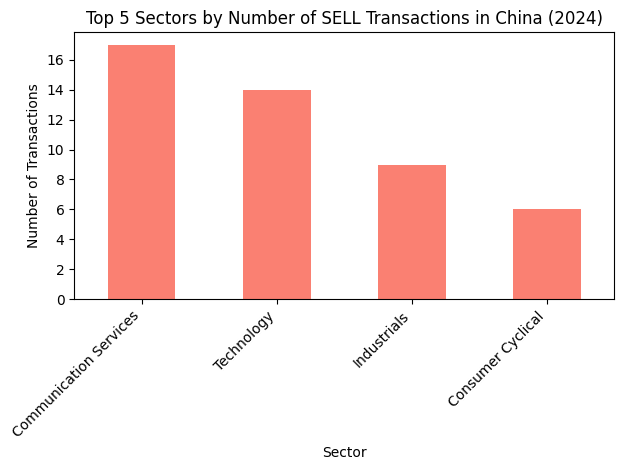

In [103]:
import matplotlib.pyplot as plt

# First, make sure symbols_df includes sector
print("Columns in symbols_df:")
print(symbols_df.columns)
print("\n")  # adding space after the printout for clarity

# If it does, merge it with china_sell:
china_sell = china_sell.merge(symbols_df[['symbol', 'sector']], on='symbol', how='left')

# Now group by sector safely:
top5_sectors = china_sell.groupby('sector').size().sort_values(ascending=False).head(5)

# Display the results as text first
print("Top 5 Sectors by Number of SELL Transactions in China (2024):")
print(top5_sectors)
print("\n")  # adding space after the printout for clarity

# Plotting the results in a bar chart
top5_sectors.plot(kind='bar', color='salmon')
plt.title('Top 5 Sectors by Number of SELL Transactions in China (2024)')
plt.xlabel('Sector')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 5 Industries by Number of BUY Transactions in Q4 2024:
industry
Semiconductors                    20
Credit Services                    7
Software - Infrastructure          7
Internet Content & Information     6
Telecom Services                   6
dtype: int64




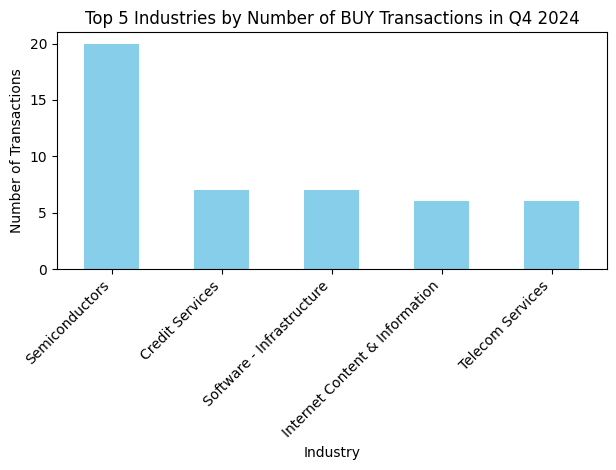

In [104]:
import matplotlib.pyplot as plt

# Filter for Q4 2024 and BUY transactions
q4_buy = merged_df[
    (merged_df['TransactionType'].str.upper() == 'BUY') & 
    (merged_df['Date'].dt.year == 2024) & 
    (merged_df['Date'].dt.month.isin([10, 11, 12]))

]

# If industry is not already in merged_df, merge with symbols_df
q4_buy = q4_buy.merge(symbols_df[['symbol', 'industry']], on='symbol', how='left')

# Now group by industry and count
top5_industries = q4_buy.groupby('industry').size().sort_values(ascending=False).head(5)

# Display the results as text first
print("Top 5 Industries by Number of BUY Transactions in Q4 2024:")
print(top5_industries)
print("\n")  # adding space after the printout for clarity

# Plotting the results in a bar chart
top5_industries.plot(kind='bar', color='skyblue')
plt.title('Top 5 Industries by Number of BUY Transactions in Q4 2024')
plt.xlabel('Industry')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ranking of Quarters by Number of Transactions in 2024:
Quarter
3    275
2    260
4    256
1    186
dtype: int64




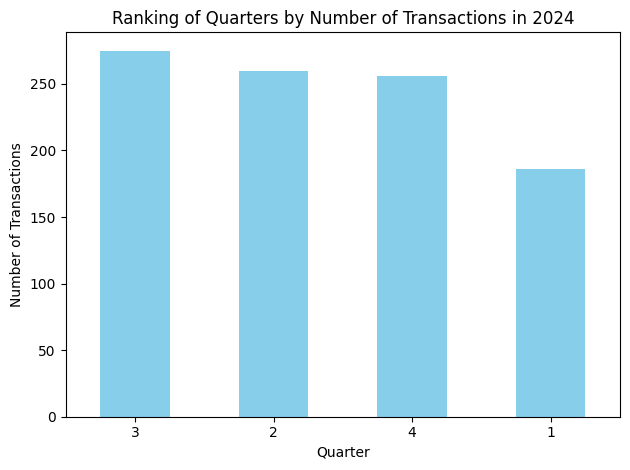

In [105]:
import matplotlib.pyplot as plt

# Filter for transactions in 2024
transactions_2024 = merged_df[merged_df['Date'].dt.year == 2024]

# Create a quarter column
transactions_2024 = transactions_2024.copy()
transactions_2024['Quarter'] = transactions_2024['Date'].dt.quarter

# Count total number of transactions per quarter
quarter_count = transactions_2024.groupby('Quarter').size().sort_values(ascending=False)

# Display the results as text first
print("Ranking of Quarters by Number of Transactions in 2024:")
print(quarter_count)
print("\n")  # adding space after the printout for clarity

# Plotting the results in a bar chart
quarter_count.plot(kind='bar', color='skyblue')
plt.title('Ranking of Quarters by Number of Transactions in 2024')
plt.xlabel('Quarter')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 countries by number of SELL transactions in 2024:
country
United States of America                                145
United Kingdom of Great Britain and Northern Ireland     51
China                                                    46
Brazil                                                   35
Taiwan                                                   25
Netherlands, Kingdom of the                              22
Ireland                                                  14
Switzerland                                              13
Luxembourg                                               12
Canada                                                   10
dtype: int64


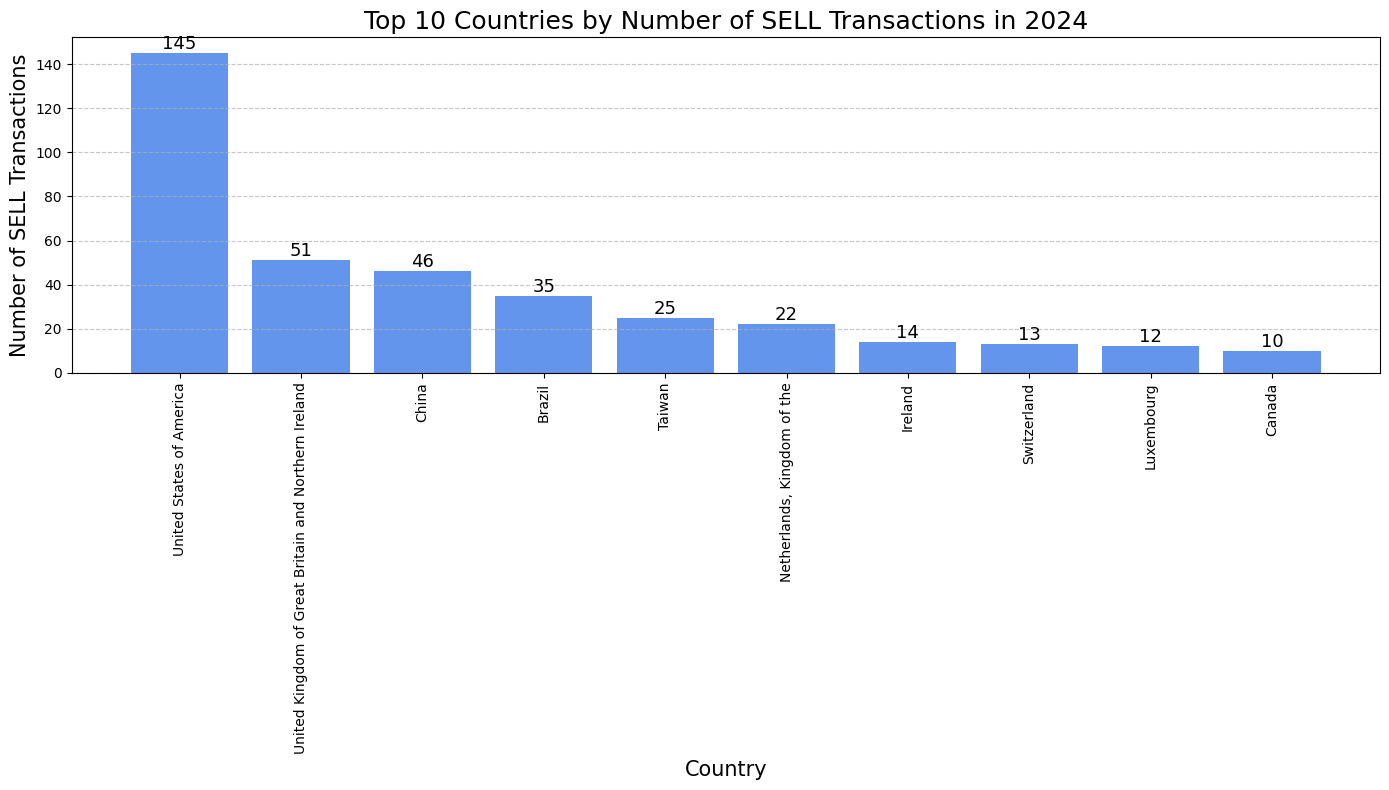

In [106]:
import matplotlib.pyplot as plt

# Filter SELL transactions in 2024
sell_2024 = merged_df[
    (merged_df['TransactionType'].str.upper() == 'SELL') &
    (merged_df['Date'].dt.year == 2024)
]

# Group by country and count transactions
top10_countries_sell = sell_2024.groupby('country').size().sort_values(ascending=False).head(10)

# Print the results
print("Top 10 countries by number of SELL transactions in 2024:")
print(top10_countries_sell)

# Using the same top10_countries_sell Series (country names as index and counts as values)

plt.figure(figsize=(14, 8))  # Larger figure for clarity and taller bars
bars = plt.bar(top10_countries_sell.index, top10_countries_sell.values, color='cornflowerblue')

plt.title('Top 10 Countries by Number of SELL Transactions in 2024', fontsize=18)
plt.xlabel('Country', fontsize=15)
plt.ylabel('Number of SELL Transactions', fontsize=15)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=13)

plt.show()

In [107]:
print(symbols_df.columns)

Index(['symbol', 'company_name', 'sector', 'industry', 'country'], dtype='object')


Top 5 Countries by Total Units Bought in 2024:
country
United States of America                                10793.0
China                                                    3576.0
United Kingdom of Great Britain and Northern Ireland     3228.0
Peru                                                     1680.0
Switzerland                                              1557.0
Name: Unit, dtype: float64


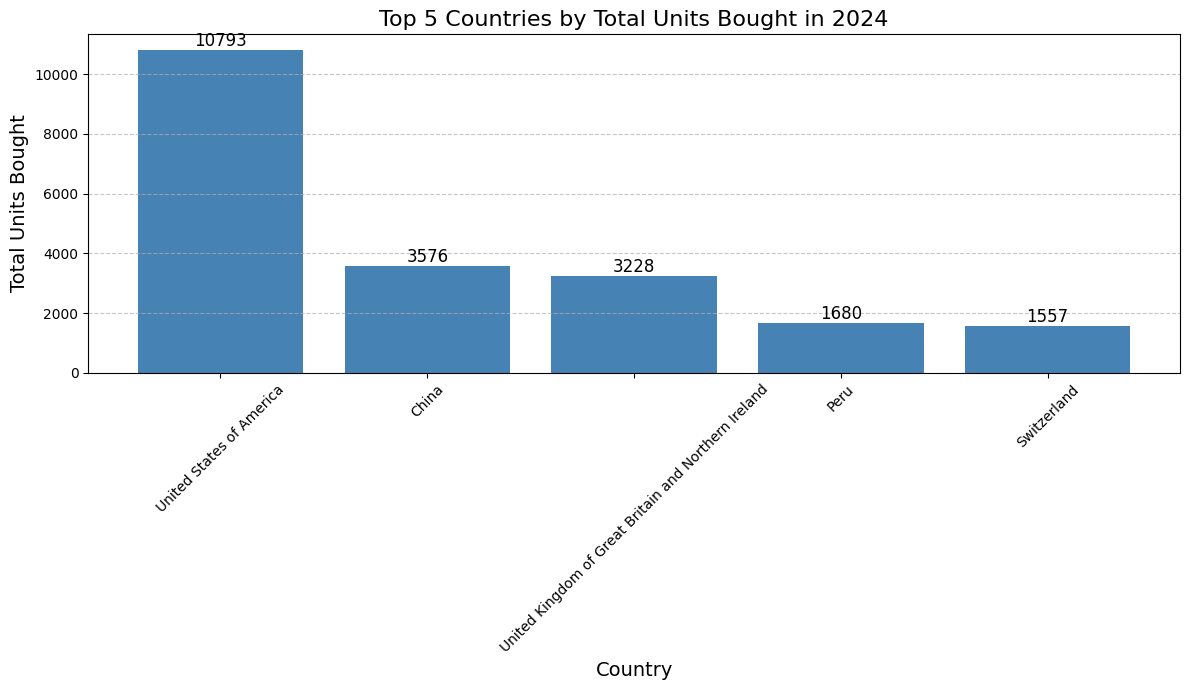

In [108]:
buy_2024 = transactions_df[
    (transactions_df['TransactionType'].str.upper() == 'BUY') &
    (transactions_df['Date'].dt.year == 2024)
]

# Merge with symbols_df to get 'country' info
buy_2024 = buy_2024.merge(symbols_df[['symbol', 'country']], on='symbol', how='left')

# Group by country and sum units
top5_countries_units_bought = buy_2024.groupby('country')['Unit'].sum().sort_values(ascending=False).head(5)

# Print results
print("Top 5 Countries by Total Units Bought in 2024:")
print(top5_countries_units_bought)

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
bars = plt.bar(top5_countries_units_bought.index, top5_countries_units_bought.values, color='steelblue')
plt.title('Top 5 Countries by Total Units Bought in 2024', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Total Units Bought', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.show()

Top 5 Sectors by Total Units Traded (BUY + SELL) in Q3 2024:
sector
Technology                3884.0
Communication Services    2349.0
Consumer Cyclical         1866.0
Healthcare                1465.0
Industrials               1461.0
Name: Unit, dtype: float64


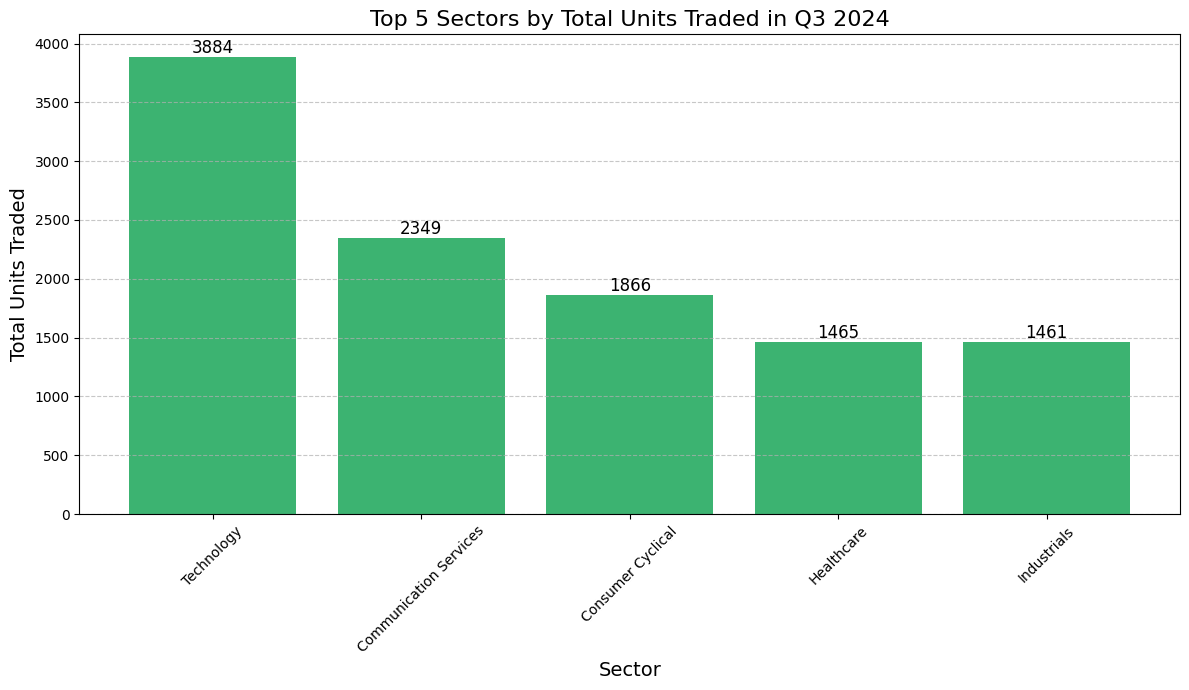

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for Q3 2024 (July to September)
q3_2024 = transactions_df[
    (transactions_df['Date'].dt.year == 2024) &
    (transactions_df['Date'].dt.month.isin([7,8,9]))
]

# Merge with symbols_df to get sector info
q3_2024 = q3_2024.merge(symbols_df[['symbol', 'sector']], on='symbol', how='left')

# Group by sector and sum units (BUY + SELL)
top5_sectors_units = q3_2024.groupby('sector')['Unit'].sum().sort_values(ascending=False).head(5)

# Print results
print("Top 5 Sectors by Total Units Traded (BUY + SELL) in Q3 2024:")
print(top5_sectors_units)

# Plotting
plt.figure(figsize=(12,7))
bars = plt.bar(top5_sectors_units.index, top5_sectors_units.values, color='mediumseagreen')
plt.title('Top 5 Sectors by Total Units Traded in Q3 2024', fontsize=16)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Total Units Traded', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adding labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Filter for 2024 transactions
transactions_2024 = transactions_df[transactions_df['Date'].dt.year == 2024]

# Count transactions by symbol
top10_symbols = transactions_2024.groupby('symbol').size().sort_values(ascending=False).head(10)

# Printing results
print("Top 10 Symbols by Number of Transactions in 2024:")
print(top10_symbols)

# Plotting
plt.figure(figsize=(12, 7))
bars = plt.bar(top10_symbols.index, top10_symbols.values, color='darkorchid')
plt.title('Top 10 Symbols by Number of Transactions in 2024', fontsize=16)
plt.xlabel('Symbol', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adding annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=12)

plt.show()

Top 5 Countries by Number of Units Traded in Financial Services:
country
United States of America    7352.0
Peru                        4434.0
Bermuda                     3658.0
China                       1663.0
Canada                      1466.0
Name: Unit, dtype: float64


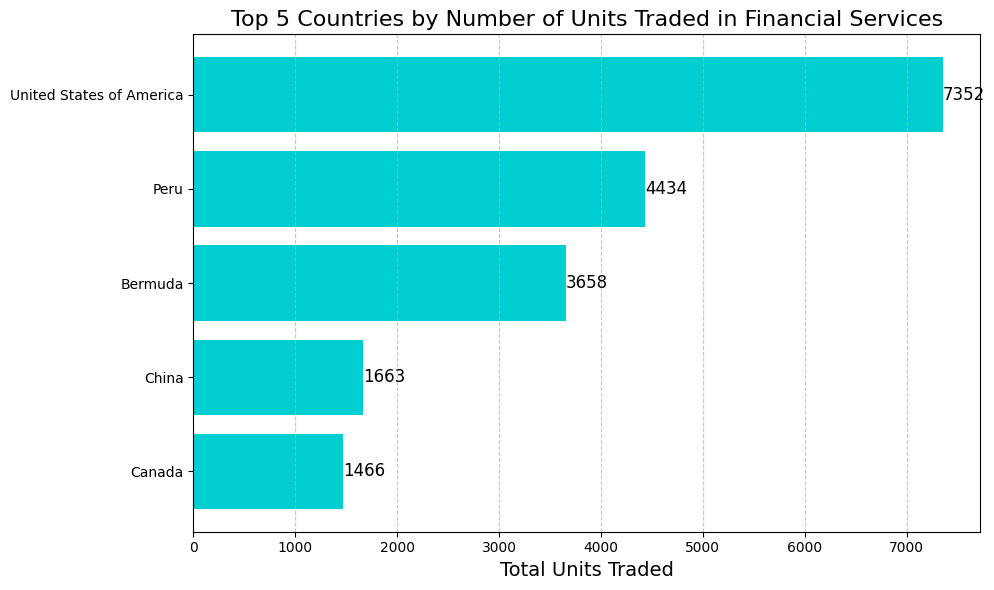

In [ ]:
import matplotlib.pyplot as plt

# Filter for Financial Services companies first
financial_services = symbols_df[symbols_df['sector'] == 'Financial Services']

# Now merge transactions with financial_services to bring in country info
financial_services_trade = transactions_df.merge(
    financial_services[['symbol', 'country']],
    on='symbol',
    how='left'
)

# Aggregate total Units by country
top5_countries = financial_services_trade.groupby('country')['Unit'].sum().sort_values(ascending=False).head(5)

# Printing results
print("Top 5 Countries by Number of Units Traded in Financial Services:")
print(top5_countries)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(top5_countries.index, top5_countries.values, color='darkturquoise')
plt.title('Top 5 Countries by Number of Units Traded in Financial Services', fontsize=16)
plt.xlabel('Total Units Traded', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()

# Adding annotations
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontsize=12)

plt.show()

Top 5 Industries by Number of Units Traded in Asia in 2024:
industry
Auto Manufacturers                1869.0
Software - Application             951.0
Credit Services                    932.0
Aerospace & Defense                887.0
Internet Content & Information     827.0
Name: Unit, dtype: float64


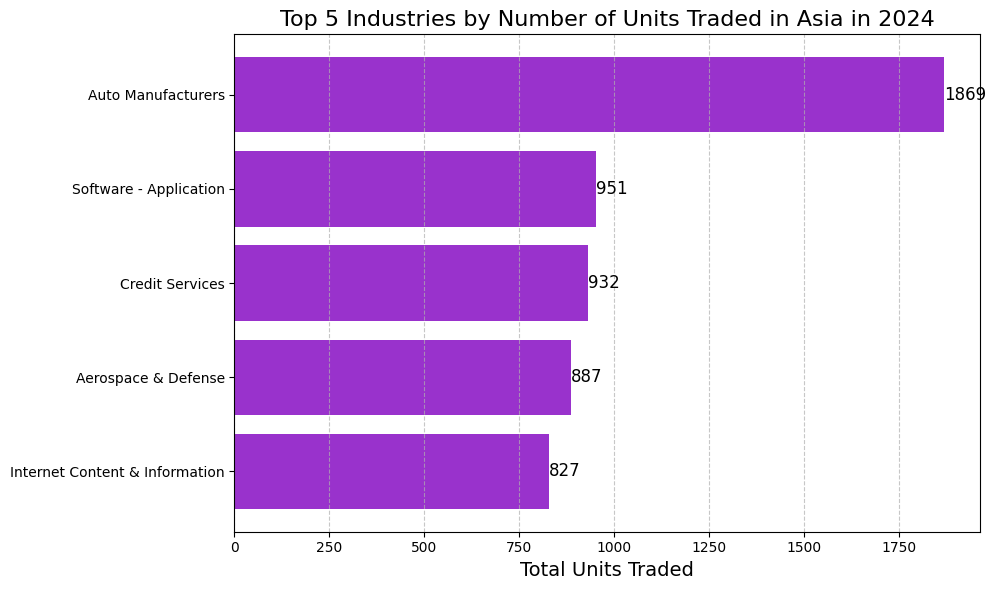

In [ ]:
import matplotlib.pyplot as plt

# Filter for 2024 transactions first
transactions_2024 = transactions_df[
    transactions_df['Date'].dt.year == 2024
]

# Now merge to bring in country and industry
transactions_2024 = transactions_2024.merge(
    symbols_df[['symbol', 'country', 'industry']],
    on='symbol',
    how='left'
)

# Filter for Asia
# (Adjust this condition if you have a predefined list of Asia countries)
asia_countries = ['China', 'Japan', 'India', 'South Korea', 'Indonesia', 'Philippines', 'Vietnam', 'Malaysia', 'Singapore']

asia_trade = transactions_2024[
    transactions_2024['country'].isin(asia_countries)
]

# Aggregate total Units by industry
top5_industries = asia_trade.groupby('industry')['Unit'].sum().sort_values(ascending=False).head(5)

# Printing results
print("Top 5 Industries by Number of Units Traded in Asia in 2024:")
print(top5_industries)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(top5_industries.index, top5_industries.values, color='darkorchid')
plt.title('Top 5 Industries by Number of Units Traded in Asia in 2024', fontsize=16)
plt.xlabel('Total Units Traded', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()

# Adding annotations
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontsize=12)

plt.show()

Top 5 Companies by Average Units per Transaction in Q2 2024:
company_name
Alvotech                    356.5
Scorpio Tankers Inc.        221.0
Arch Capital Group Ltd.     214.0
Mastercard Incorporated     177.0
Heron Therapeutics, Inc.    132.0
Name: Unit, dtype: float64


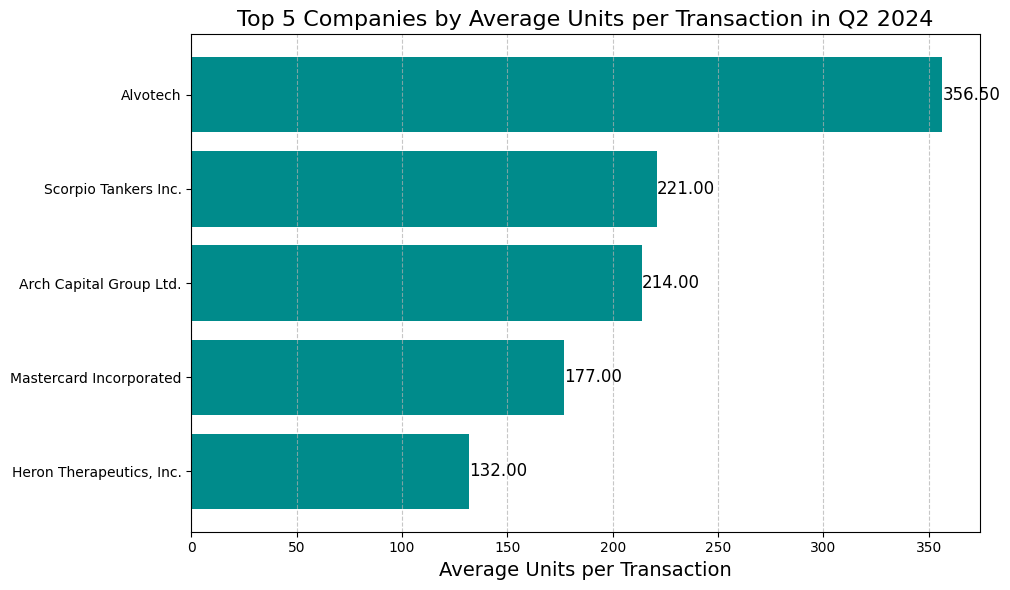

In [ ]:
import matplotlib.pyplot as plt

# Filter for Q2 of 2024 (Apr, May, June)
q2_2024 = transactions_df[
    (transactions_df['Date'].dt.year == 2024) & 
    (transactions_df['Date'].dt.quarter == 2)
]

# Now merge to bring in company information
q2_2024 = q2_2024.merge(
    symbols_df[['symbol', 'company_name']],
    on='symbol',
    how='left'
)

# Calculate average Units per transaction by company
average_units = q2_2024.groupby('company_name')['Unit'].mean().sort_values(ascending=False).head(5)

# Printing results
print("Top 5 Companies by Average Units per Transaction in Q2 2024:")
print(average_units)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(average_units.index, average_units.values, color='darkcyan')
plt.title('Top 5 Companies by Average Units per Transaction in Q2 2024', fontsize=16)
plt.xlabel('Average Units per Transaction', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()

# Adding annotations
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             ha='left', va='center', fontsize=12)

plt.show()

In [ ]:
print(transactions_df.columns)
print(symbols_df.columns)
print(countries_df.columns)

Index(['IDTransaction', 'Date', 'TransactionType', 'symbol', 'Unit'], dtype='object')
Index(['symbol', 'company_name', 'sector', 'industry', 'country'], dtype='object')
Index(['country_code', 'country_name', 'region', 'sub_region'], dtype='object')


Top 5 Sub-Regions by Number of Transactions in Q4 2024:
sub_region
Northern America                   106
Northern Europe                     36
Eastern Asia                        29
Latin America and the Caribbean     29
Western Europe                      16
dtype: int64


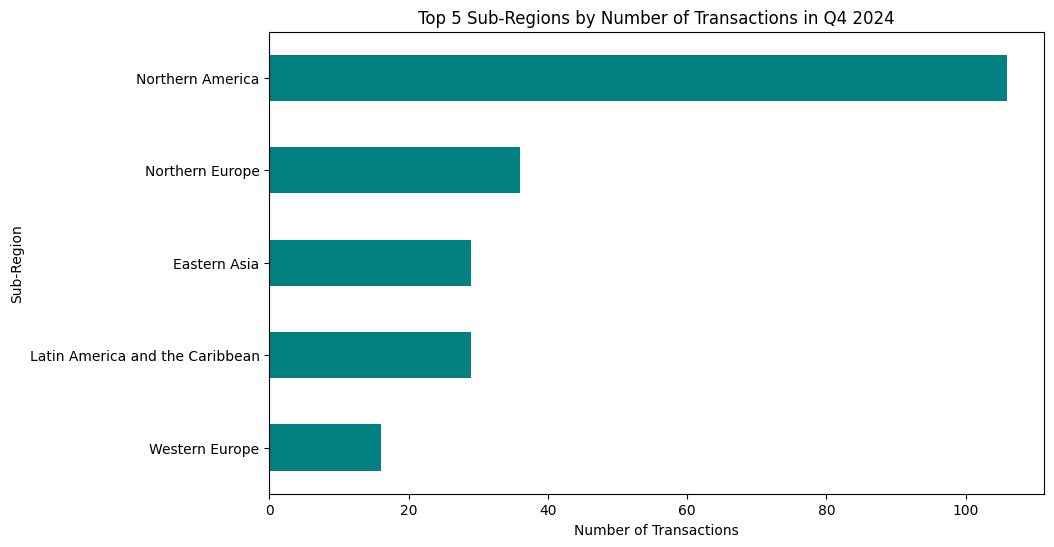

In [ ]:
# 1. Merge transactions with symbols to get country
transactions_symbols = transactions_df.merge(symbols_df[['symbol', 'country']], on='symbol', how='left')

# 2. Merge with countries_df to get sub_region
# Assuming transactions_symbols['country'] matches countries_df['country_name']
transactions_full = transactions_symbols.merge(
    countries_df[['country_name', 'sub_region']],
    left_on='country',
    right_on='country_name',
    how='left'
)

# 3. Filter for Q4 2024
q4_2024 = transactions_full[
    (transactions_full['Date'].dt.year == 2024) &
    (transactions_full['Date'].dt.quarter == 4)
]

# 4. Group by sub_region and count transactions
top5_subregions = q4_2024.groupby('sub_region').size().sort_values(ascending=False).head(5)

# 5. Print and plot
print("Top 5 Sub-Regions by Number of Transactions in Q4 2024:")
print(top5_subregions)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top5_subregions.plot(kind='barh', color='teal')
plt.title('Top 5 Sub-Regions by Number of Transactions in Q4 2024')
plt.xlabel('Number of Transactions')
plt.ylabel('Sub-Region')
plt.gca().invert_yaxis()  # highest on top
plt.show()